# Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Unzip the dataset

In [ ]:
"""import zipfile

zip_path = "/content/drive/MyDrive/gurmukhi-dt-data/dataset.zip"
extract_path = "/content/drive/MyDrive/gurmukhi-dt-data/gurmukhi_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted!")

Extracted!


Verify all 41 folders came through

In [ ]:
import os
nested_path = os.path.join(extract_path, "dataset")
print(sorted(os.listdir(nested_path), key=lambda x: int(x) if x.isdigit() else 999))

['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41']


# Exploring the dataset

Class identification

In [ ]:
import os
data_path = "/content/drive/MyDrive/gurmukhi-dt-data/gurmukhi_dataset/dataset"
classes = os.listdir(data_path)
print(len(classes), "classes found")
print(sorted(classes, key=lambda x: int(x)))

41 classes found
['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41']


Peek into one class folder

In [ ]:
class_name = classes[0]
class_folder = f"{data_path}/{class_name}"
images = os.listdir(class_folder)
print(f"Class '{class_name}' has {len(images)} images")
print(images[:5])

Class '1' has 297 images
['1.jpg', 'aug_0_10.jpg', 'aug_0_1024.jpg', 'aug_0_1042.jpg', 'aug_0_1056.jpg']


Count images in every class

In [ ]:
class_counts = {}
for c in classes:
    folder = f"{data_path}/{c}"
    class_counts[c] = len(os.listdir(folder))

for c in sorted(class_counts, key=lambda x: int(x)):
    print(f"Class {c}: {class_counts[c]} images")

print("\nTotal images:", sum(class_counts.values()))

Class 1: 297 images
Class 2: 299 images
Class 3: 294 images
Class 4: 295 images
Class 5: 297 images
Class 6: 296 images
Class 7: 293 images
Class 8: 297 images
Class 9: 295 images
Class 10: 294 images
Class 11: 292 images
Class 12: 296 images
Class 13: 296 images
Class 14: 299 images
Class 15: 294 images
Class 16: 298 images
Class 17: 297 images
Class 18: 296 images
Class 19: 294 images
Class 20: 297 images
Class 21: 296 images
Class 22: 295 images
Class 23: 299 images
Class 24: 296 images
Class 25: 298 images
Class 26: 297 images
Class 27: 291 images
Class 28: 297 images
Class 29: 292 images
Class 30: 299 images
Class 31: 296 images
Class 32: 298 images
Class 33: 294 images
Class 34: 294 images
Class 35: 297 images
Class 36: 299 images
Class 37: 296 images
Class 38: 297 images
Class 39: 295 images
Class 40: 293 images
Class 41: 293 images

Total images: 12128


Visualize the counts as a bar chart

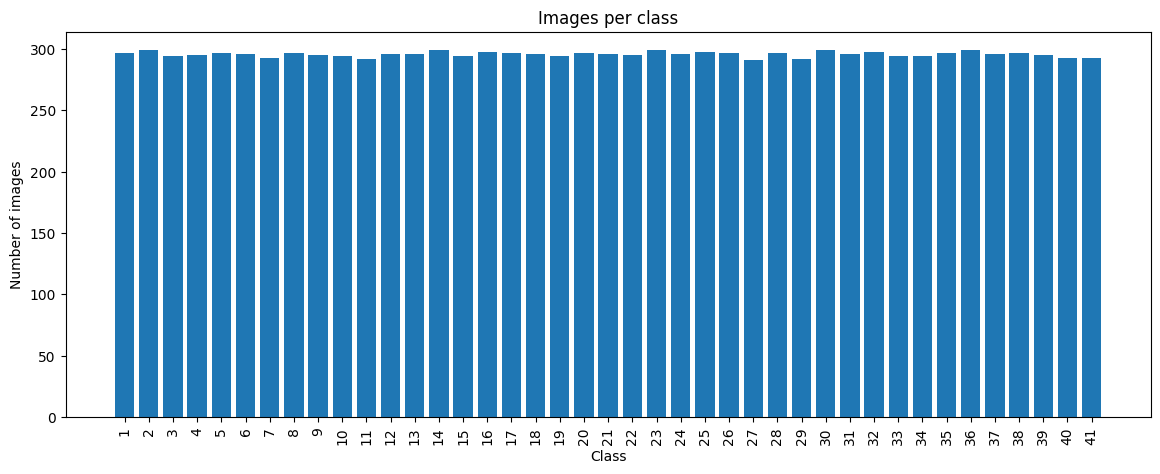

In [ ]:
import matplotlib.pyplot as plt

sorted_classes = sorted(class_counts, key=lambda x: int(x))
counts = [class_counts[c] for c in sorted_classes]

plt.figure(figsize=(14,5))
plt.bar(sorted_classes, counts)
plt.xlabel("Class")
plt.ylabel("Number of images")
plt.title("Images per class")
plt.xticks(rotation=90)
plt.show()

Visualizing Sample Images from Different Classes

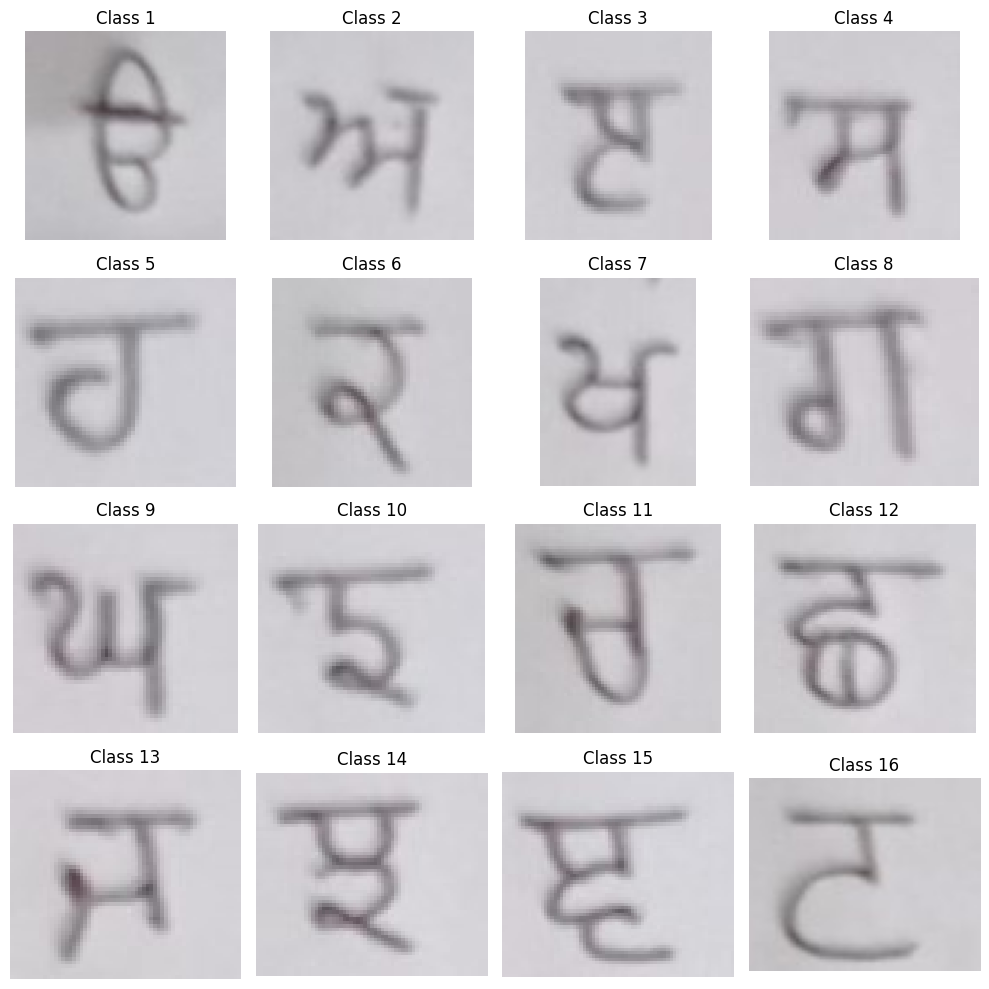

In [9]:
import cv2
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 4, figsize=(10,10))
sample_classes = sorted(classes, key=lambda x: int(x))[:16]

for ax, c in zip(axes.flat, sample_classes):
    folder = f"{data_path}/{c}"
    img_file = os.listdir(folder)[0]
    img = cv2.imread(f"{folder}/{img_file}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(f"Class {c}")
    ax.axis('off')

plt.tight_layout()
plt.show()

Checking Sample Image Dimensions:

In [10]:
sample_img = cv2.imread(f"{data_path}/1/{os.listdir(f'{data_path}/1')[0]}")
print("Image shape:", sample_img.shape)

Image shape: (79, 76, 3)


# Image Preprocessing and Visualization

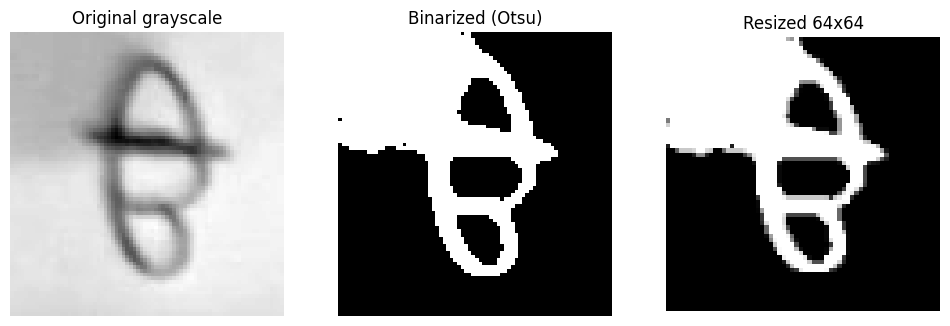

In [11]:
sample_path = f"{data_path}/1/{os.listdir(f'{data_path}/1')[0]}"
img = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)

_, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
resized = cv2.resize(binary, (64, 64))

fig, axes = plt.subplots(1, 3, figsize=(12,4))
axes[0].imshow(img, cmap='gray'); axes[0].set_title("Original grayscale")
axes[1].imshow(binary, cmap='gray'); axes[1].set_title("Binarized (Otsu)")
axes[2].imshow(resized, cmap='gray'); axes[2].set_title("Resized 64x64")
for ax in axes: ax.axis('off')
plt.show()

Preprocessing and Loading the Complete Dataset

In [12]:
import numpy as np
from tqdm import tqdm

def preprocess_image(img_path, size=64):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    _, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    resized = cv2.resize(binary, (size, size))
    return resized / 255.0

X_images = []
y_labels = []

for c in tqdm(sorted(classes, key=lambda x: int(x))):
    folder = f"{data_path}/{c}"
    for img_file in os.listdir(folder):
        img_path = f"{folder}/{img_file}"
        processed = preprocess_image(img_path)
        X_images.append(processed)
        y_labels.append(c)

X_images = np.array(X_images)
y_labels = np.array(y_labels)

print("X_images shape:", X_images.shape)
print("y_labels shape:", y_labels.shape)

100%|██████████| 41/41 [00:47<00:00,  1.17s/it]


X_images shape: (12128, 64, 64)
y_labels shape: (12128,)


Saving the Preprocessed Dataset

In [13]:
np.save("/content/drive/MyDrive/gurmukhi-dt-data/X_images.npy", X_images)
np.save("/content/drive/MyDrive/gurmukhi-dt-data/y_labels.npy", y_labels)
print("Saved!")

Saved!


Loading the Preprocessed Dataset

In [14]:
X_images = np.load("/content/drive/MyDrive/gurmukhi-dt-data/X_images.npy")
y_labels = np.load("/content/drive/MyDrive/gurmukhi-dt-data/y_labels.npy")

Extracting HOG Features from Images

In [15]:
from skimage.feature import hog
from tqdm import tqdm

X_features = []

for img in tqdm(X_images):
    features = hog(img, orientations=9, pixels_per_cell=(8,8),
                    cells_per_block=(2,2), feature_vector=True)
    X_features.append(features)

X_features = np.array(X_features)
print("X_features shape:", X_features.shape)

100%|██████████| 12128/12128 [00:20<00:00, 595.54it/s]

X_features shape: (12128, 1764)


Saving the Extracted HOG Features

In [16]:
np.save("/content/drive/MyDrive/gurmukhi-dt-data/X_features.npy", X_features)
print("Saved!")

Saved!


Splitting the Dataset

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_labels, test_size=0.2, stratify=y_labels, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (9702, 1764)
Test shape: (2426, 1764)


Training the Decision Tree Classification Model

In [18]:
from sklearn.tree import DecisionTreeClassifier
import time

start = time.time()
clf = DecisionTreeClassifier(criterion='gini', max_depth=20, random_state=42)
clf.fit(X_train, y_train)
end = time.time()

print(f"Training completed in {end-start:.2f} seconds")

Training completed in 22.62 seconds


Evaluating the Decision Tree Model

In [19]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy*100:.2f}%\n")

print(classification_report(y_test, y_pred))

Test Accuracy: 23.21%

              precision    recall  f1-score   support

           1       0.15      0.25      0.19        59
          10       0.09      0.25      0.14        59
          11       0.10      0.16      0.12        58
          12       0.53      0.31      0.39        59
          13       0.20      0.15      0.17        59
          14       0.17      0.37      0.23        60
          15       0.23      0.17      0.19        59
          16       0.35      0.27      0.30        60
          17       0.35      0.25      0.29        59
          18       0.20      0.22      0.21        59
          19       0.23      0.19      0.21        59
           2       0.18      0.23      0.20        60
          20       0.16      0.24      0.19        59
          21       0.04      0.03      0.03        59
          22       0.29      0.20      0.24        59
          23       0.26      0.35      0.30        60
          24       0.30      0.24      0.27        59
    

Generating the Confusion Matrix

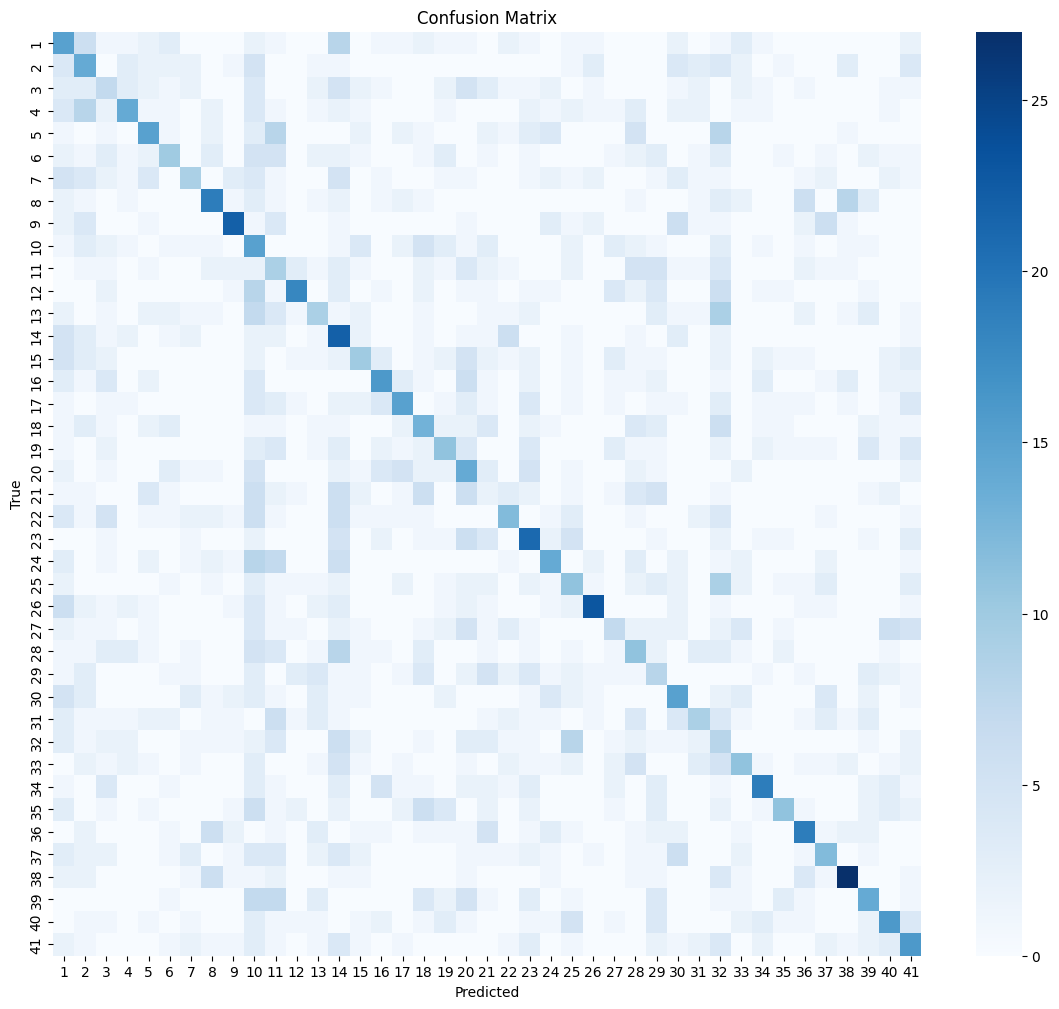

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred, labels=sorted(classes, key=lambda x: int(x)))

plt.figure(figsize=(14,12))
sns.heatmap(cm, annot=False, cmap='Blues',
            xticklabels=sorted(classes, key=lambda x: int(x)),
            yticklabels=sorted(classes, key=lambda x: int(x)))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

Checking for Overfitting/Underfitting

In [21]:
train_pred = clf.predict(X_train)
train_accuracy = accuracy_score(y_train, train_pred)
print(f"Train Accuracy: {train_accuracy*100:.2f}%")
print(f"Test Accuracy: {accuracy*100:.2f}%")

Train Accuracy: 68.93%
Test Accuracy: 23.21%


Retraining without depth restriction

In [22]:
clf_full = DecisionTreeClassifier(criterion='gini', random_state=42)
clf_full.fit(X_train, y_train)

train_pred_full = clf_full.predict(X_train)
test_pred_full = clf_full.predict(X_test)

print(f"Train Accuracy (no depth limit): {accuracy_score(y_train, train_pred_full)*100:.2f}%")
print(f"Test Accuracy (no depth limit): {accuracy_score(y_test, test_pred_full)*100:.2f}%")

Train Accuracy (no depth limit): 100.00%
Test Accuracy (no depth limit): 24.36%


Hyperparameter Tuning via GridSearchCV

In [23]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [10, 15, 20, 25, 30],
    'min_samples_leaf': [1, 5, 10, 20],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

start = time.time()
grid_search.fit(X_train, y_train)
end = time.time()

print(f"Grid search completed in {end-start:.2f} seconds")
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy: {:.2f}%".format(grid_search.best_score_ * 100))

Fitting 3 folds for each of 40 candidates, totalling 120 fits
Grid search completed in 2005.11 seconds
Best parameters: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 1}
Best cross-validation accuracy: 25.63%


Training Final Model with Best Parameters

In [31]:
clf = grid_search.best_estimator_

y_pred = clf.predict(X_test)

train_accuracy = accuracy_score(y_train, clf.predict(X_train))
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Train Accuracy: {train_accuracy*100:.2f}%")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print()
print(classification_report(y_test, y_pred))

Train Accuracy: 100.00%
Test Accuracy: 61.17%

              precision    recall  f1-score   support

           1       0.20      0.19      0.19        59
          10       0.22      0.25      0.24        59
          11       0.27      0.31      0.29        58
          12       0.48      0.39      0.43        59
          13       0.22      0.19      0.20        59
          14       0.22      0.18      0.20        60
          15       0.22      0.22      0.22        59
          16       0.35      0.37      0.36        60
          17       0.26      0.24      0.25        59
          18       0.25      0.24      0.24        59
          19       0.36      0.36      0.36        59
           2       0.26      0.23      0.25        60
          20       0.31      0.32      0.32        59
          21       0.14      0.12      0.13        59
          22       0.24      0.25      0.25        59
          23       0.36      0.35      0.35        60
          24       0.51      0.49 

Confusion Matrix

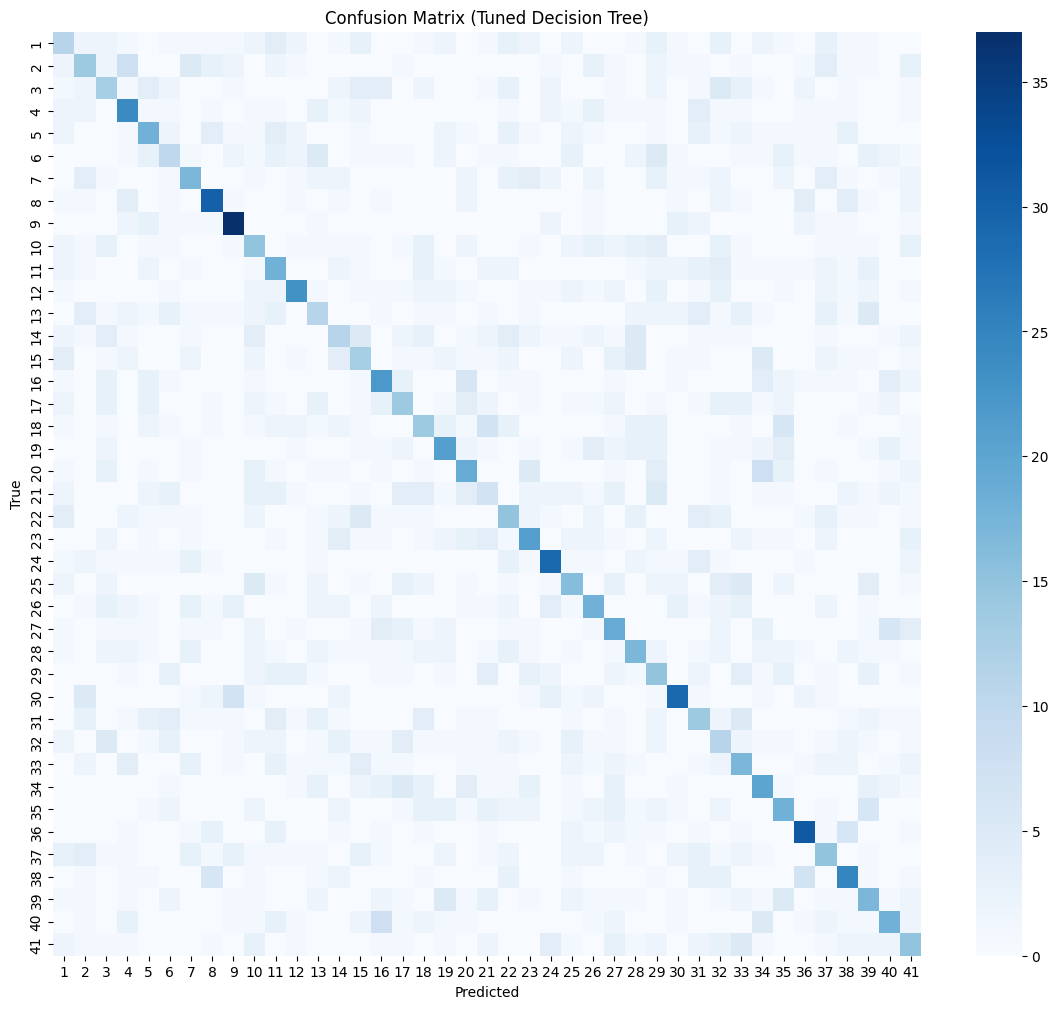

In [25]:
cm = confusion_matrix(y_test, y_pred, labels=sorted(classes, key=lambda x: int(x)))

plt.figure(figsize=(14,12))
sns.heatmap(cm, annot=False, cmap='Blues',
            xticklabels=sorted(classes, key=lambda x: int(x)),
            yticklabels=sorted(classes, key=lambda x: int(x)))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Tuned Decision Tree)")
plt.show()